In [1]:
import uproot, glob, pickle
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob, pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep
from sklearn.metrics import auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
import scipy
from scipy.stats import norm
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-13y03jsz because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
out_dir='../analysis_run3/AN_Note_Plot/unbiasing_plots_from_pkl_file'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
in_dir = "../conversion_plot_scripts"
in_file1 = "IMG_ATo2Tau_m3p6To18_pt30To300_am_apt.pkl"
in_file2 = "IMG_ATo2Tau_m0To3p6_pt30To300_am_apt.pkl"


Toatal files : 3106 Total events :  2815842 Events_per_file 906.5814552479072


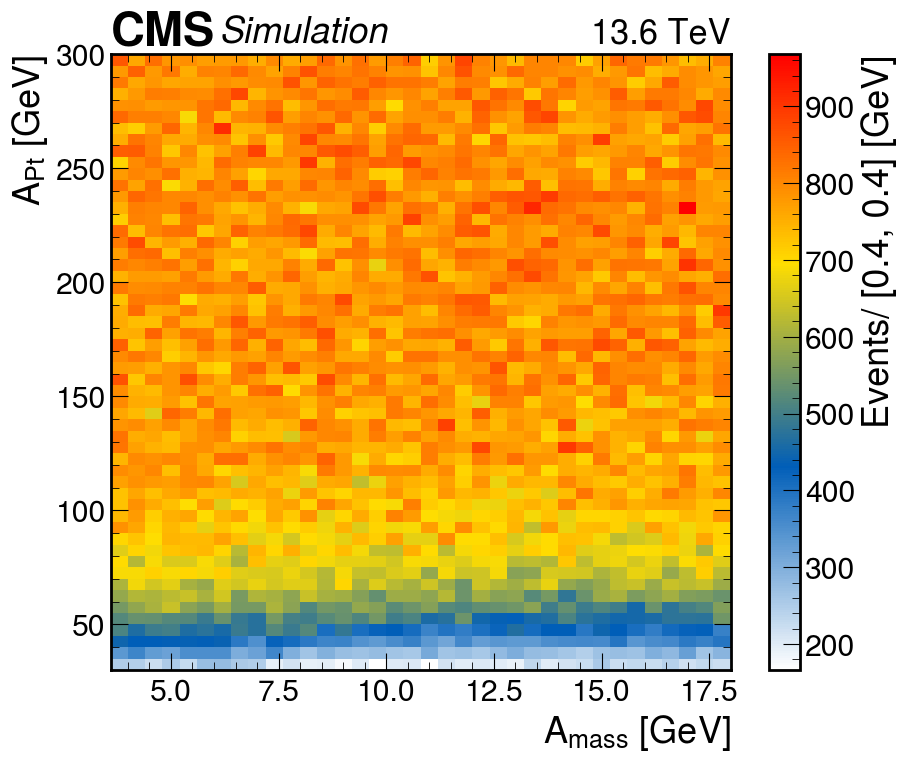

166.0 968.0 724.2391975308642


In [4]:

infile = open(f"{in_dir}/{in_file1}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=3.6
m0_max=18.1
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=100)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)])
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig('%s/%d_mtrue_mpred_2D_hist_full.png'%(out_dir, epoch), bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

Toatal files : 1678 Total events :  1708124 Events_per_file 1017.9523241954709


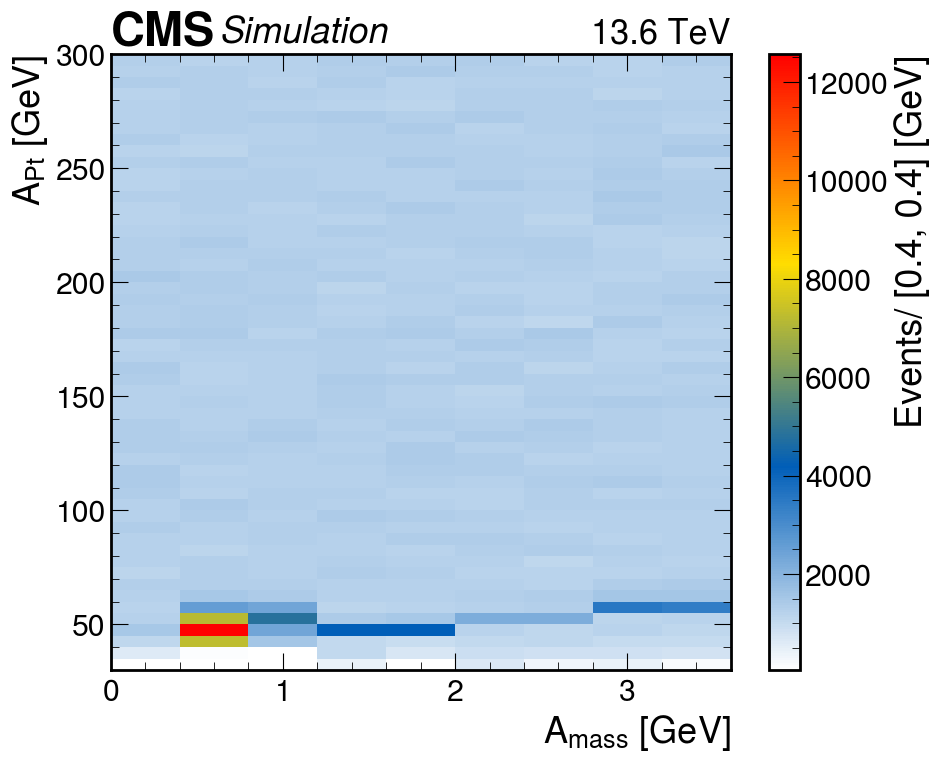

47.0 12565.0 1331.1893004115227


In [5]:
infile = open(f"{in_dir}/{in_file2}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=0
m0_max=3.7
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=100)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)])
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig('%s/%d_mtrue_mpred_2D_hist_full.png'%(out_dir, epoch), bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

Toatal files : 1 Total events :  4331532 Events_per_file 4331532.0


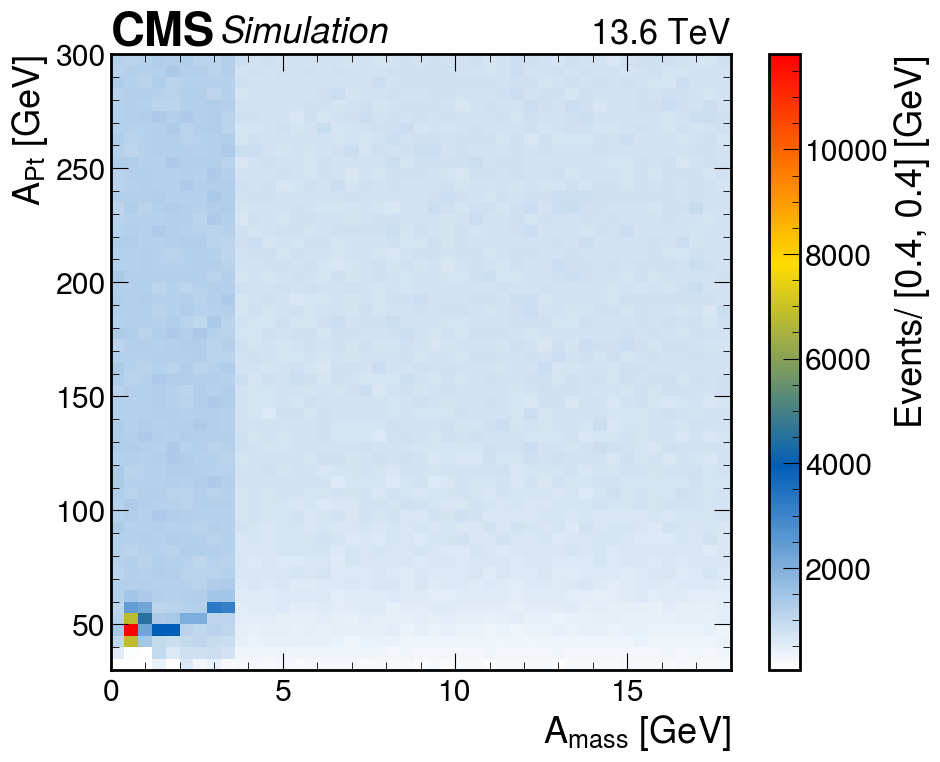

45.0 11821.0 811.1234567901234


In [7]:
in_file3 = "IMG_ATo2Tau_m0To18_pt30To300_am_apt_train.pkl"
infile = open(f"{in_dir}/{in_file3}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=0
m0_max=18.1
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=100)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)], cmap = cms_cmap)
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig('%s/%d_mtrue_mpred_2D_hist_full.png'%(out_dir, epoch), bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

In [49]:
counts = counts.flatten()
counts_below = counts[counts>200]

print(len(counts))
print("% beowl 2400  :", len(counts_below)/len(counts))

2430
% beowl 2400  : 0.9917695473251029


Toatal files : 1 Total events :  4331532 Events_per_file 4331532.0


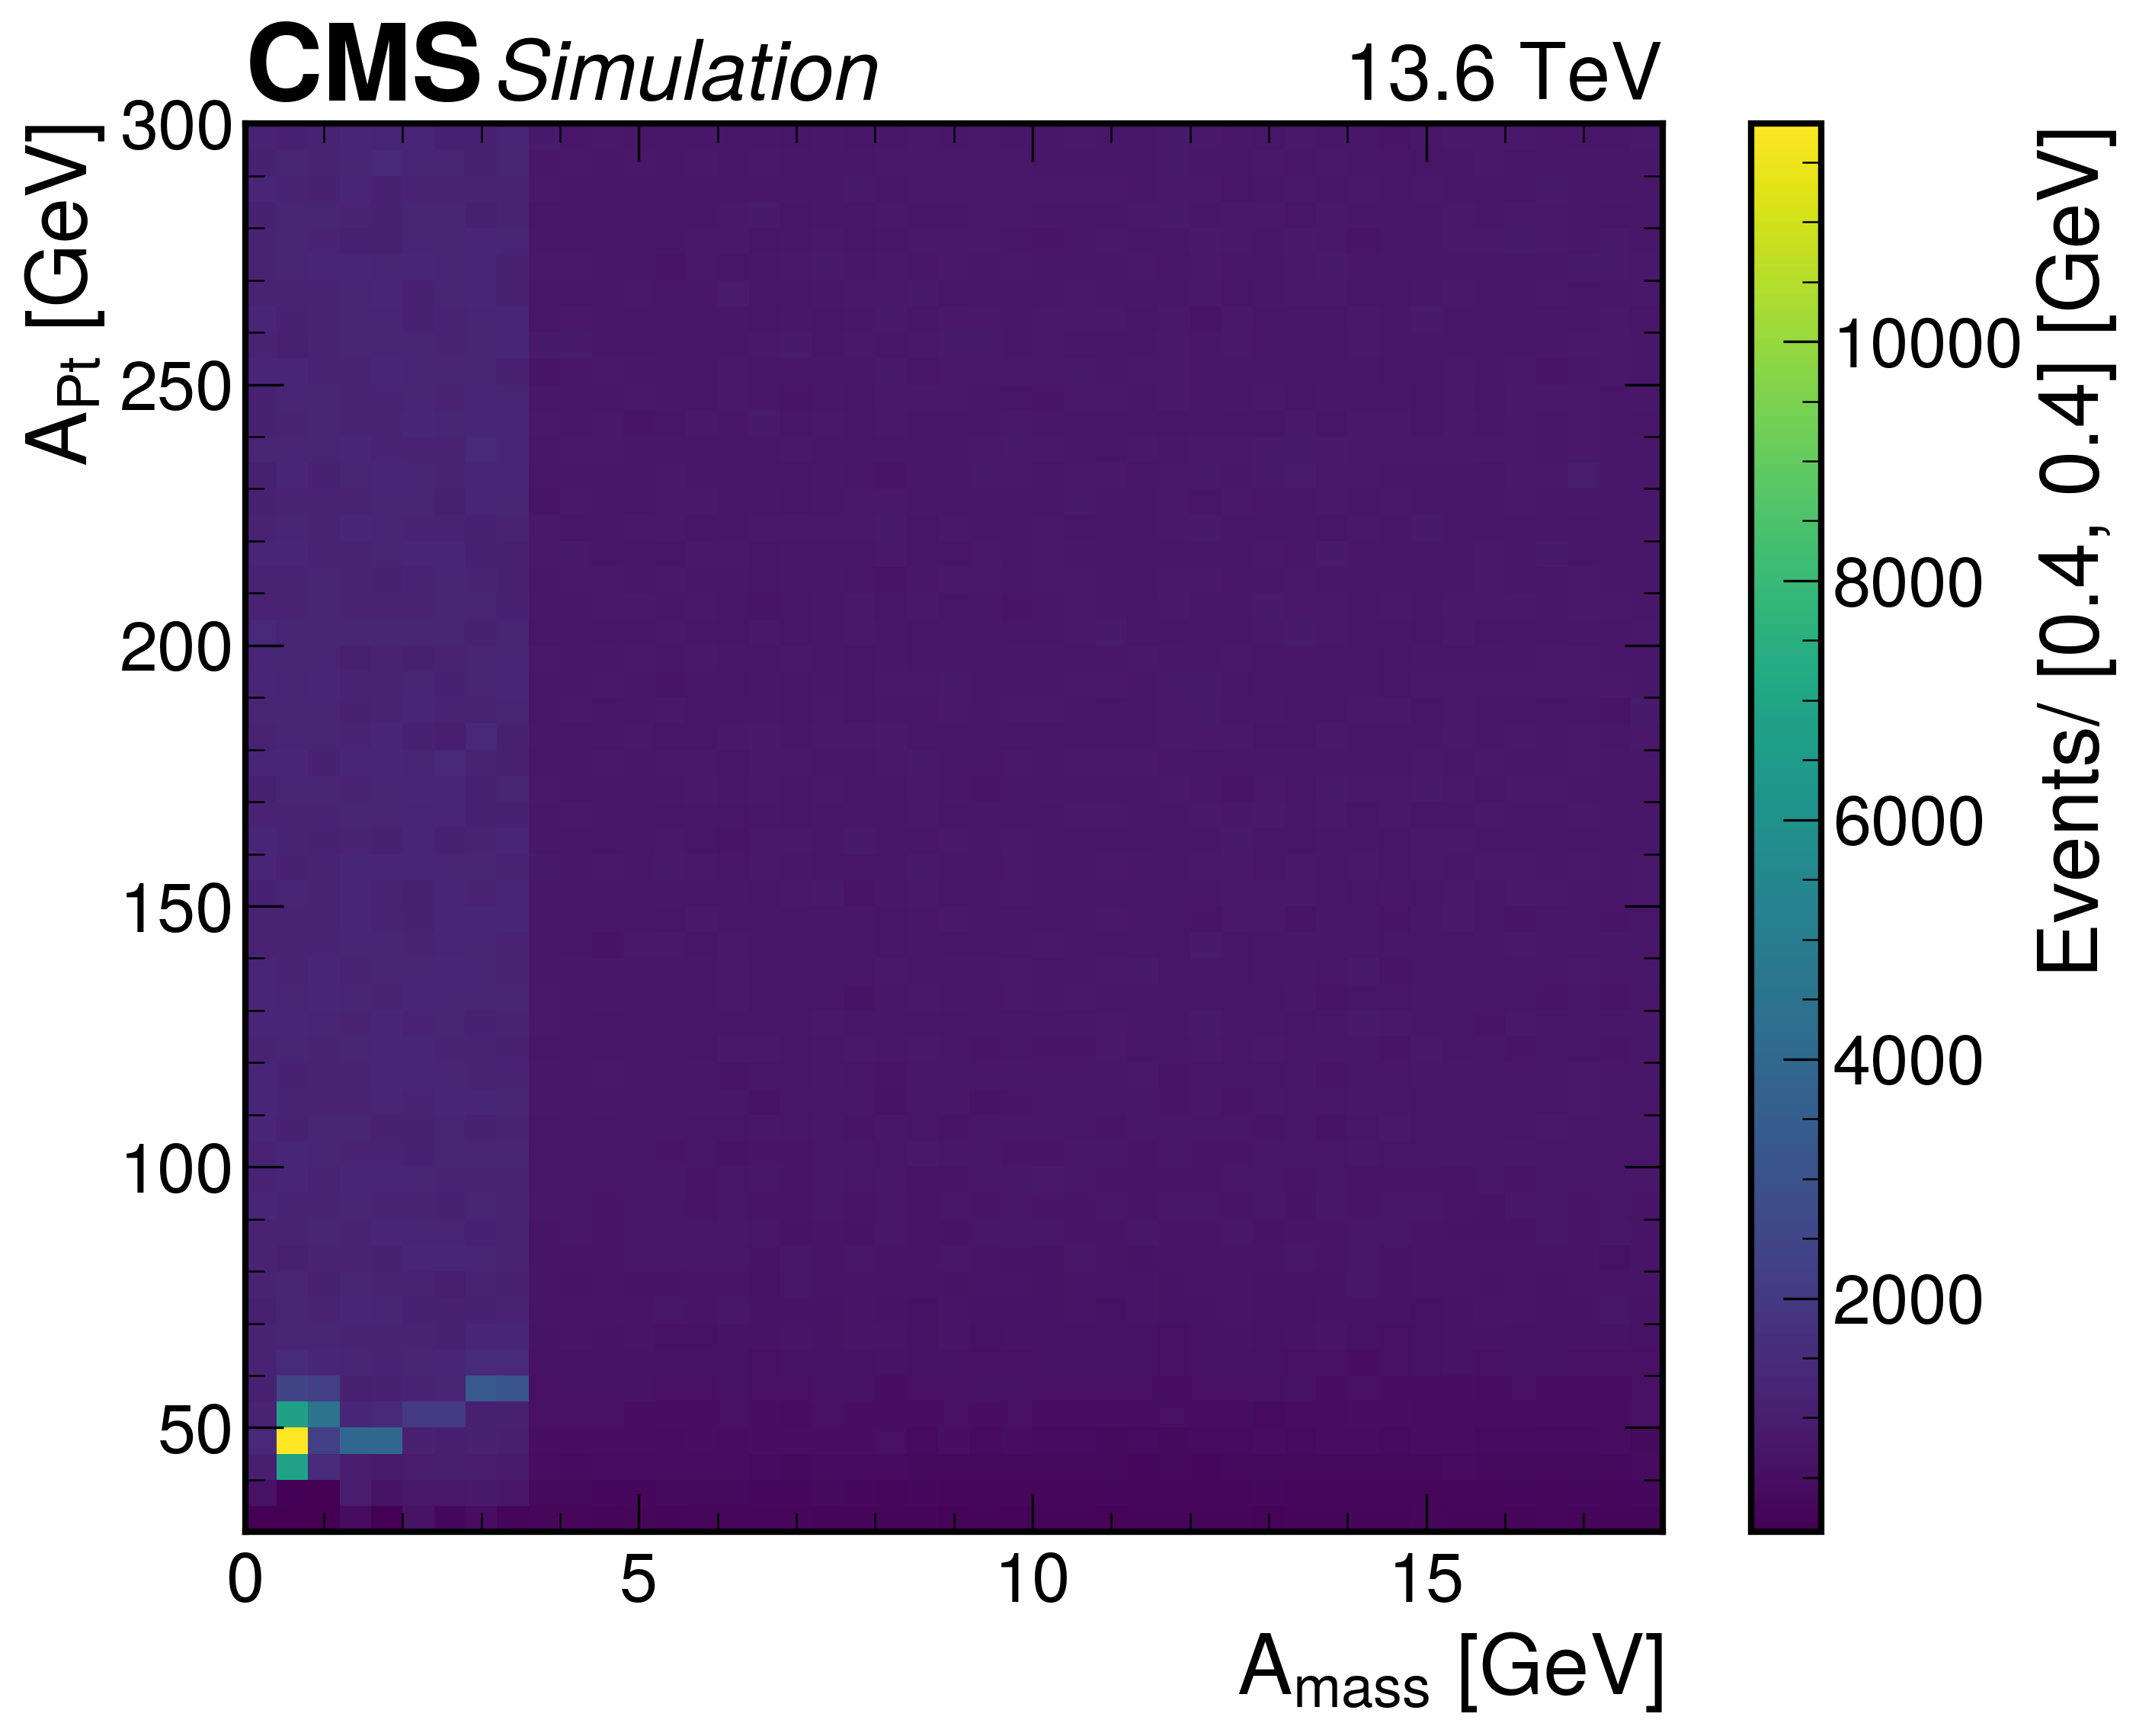

45.0 11821.0 811.1234567901234


In [10]:
in_file4 = "IMG_ATo2Tau_m0To18_pt30To300_am_apt_valid.pkl"
infile = open(f"{in_dir}/{in_file3}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=0
m0_max=18.1
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)])
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig('%s/A_maas_pt_2D_hist.pdf'%out_dir, bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

In [50]:
counts = counts.flatten()
counts_below = counts[counts>200]

print(len(counts))
print("% beowl 2400  :", len(counts_below)/len(counts))

2430
% beowl 2400  : 0.9917695473251029


Toatal files : 1 Total events :  969944 Events_per_file 969944.0


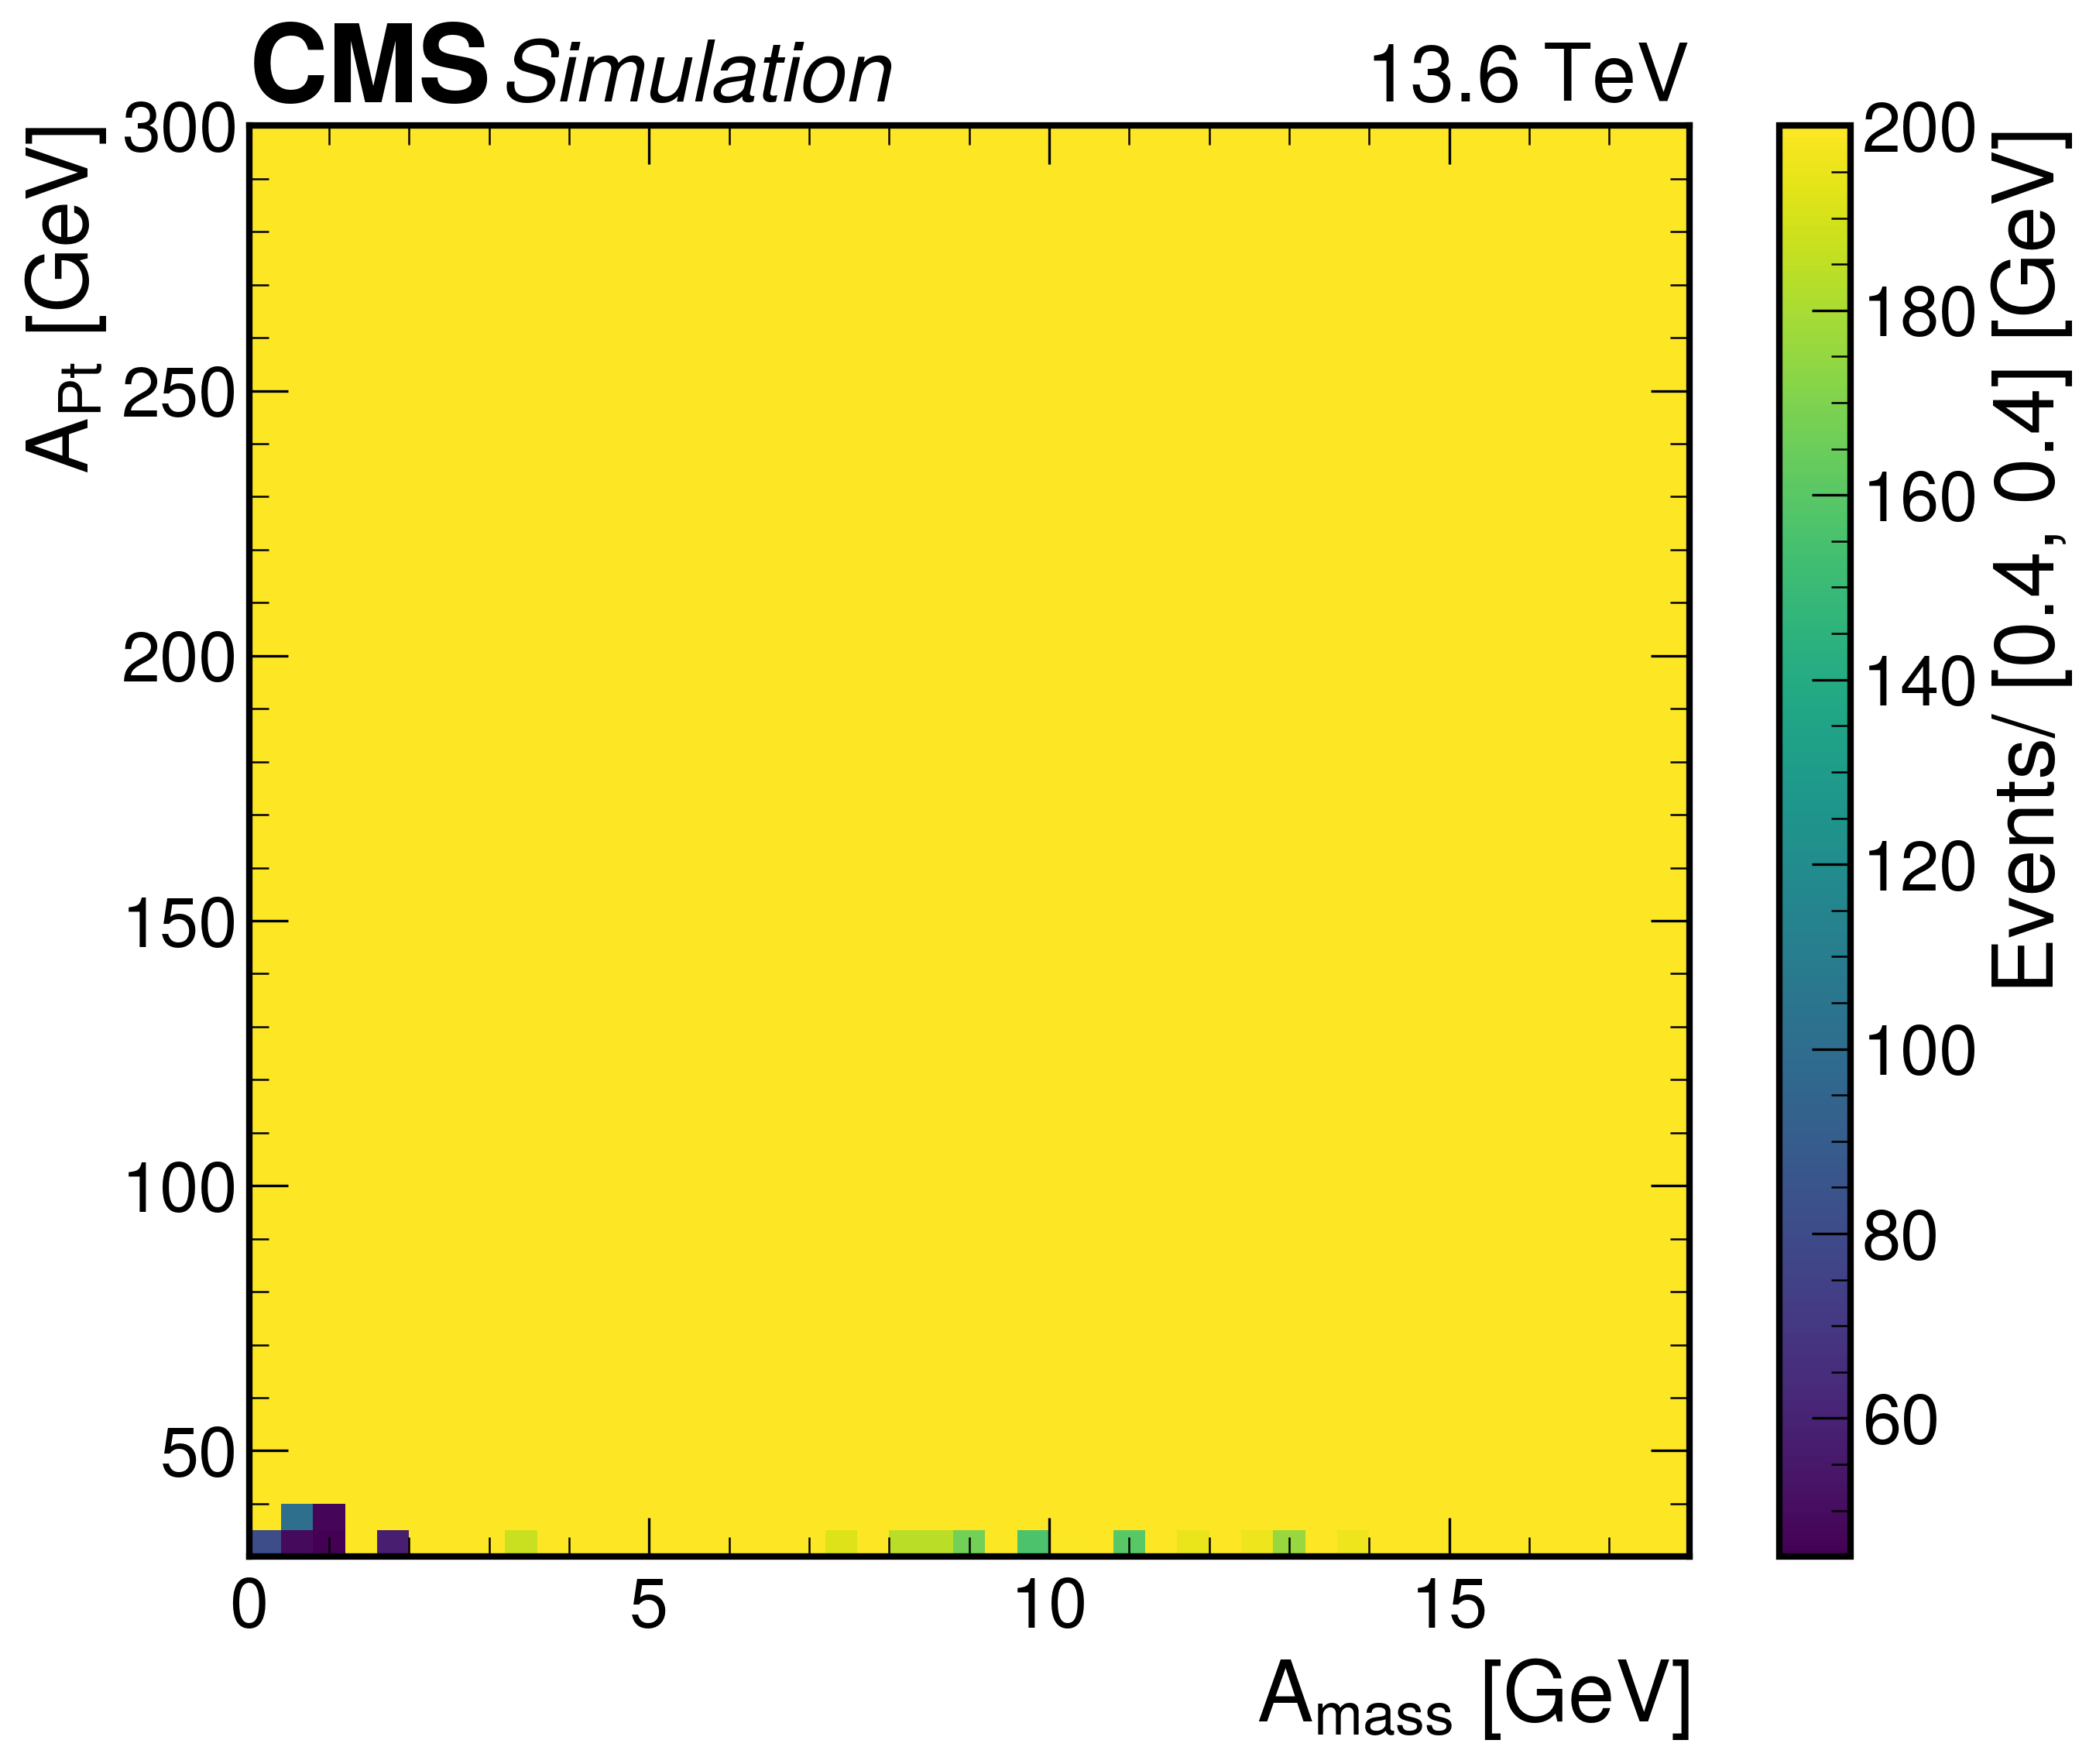

45.0 200.0 199.5769547325103


In [16]:
in_file5='IMG_ATo2Tau_m0To18_pt30To300_am_apt_from_AOD_unbiased_train.pkl'
infile = open(f"{in_dir}/{in_file5}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=0
m0_max=18.1
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=300)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)])
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
plt.savefig('%s/A_maas_pt_2D_hist_unbiased.pdf'%out_dir, bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

Toatal files : 1 Total events :  90224 Events_per_file 90224.0


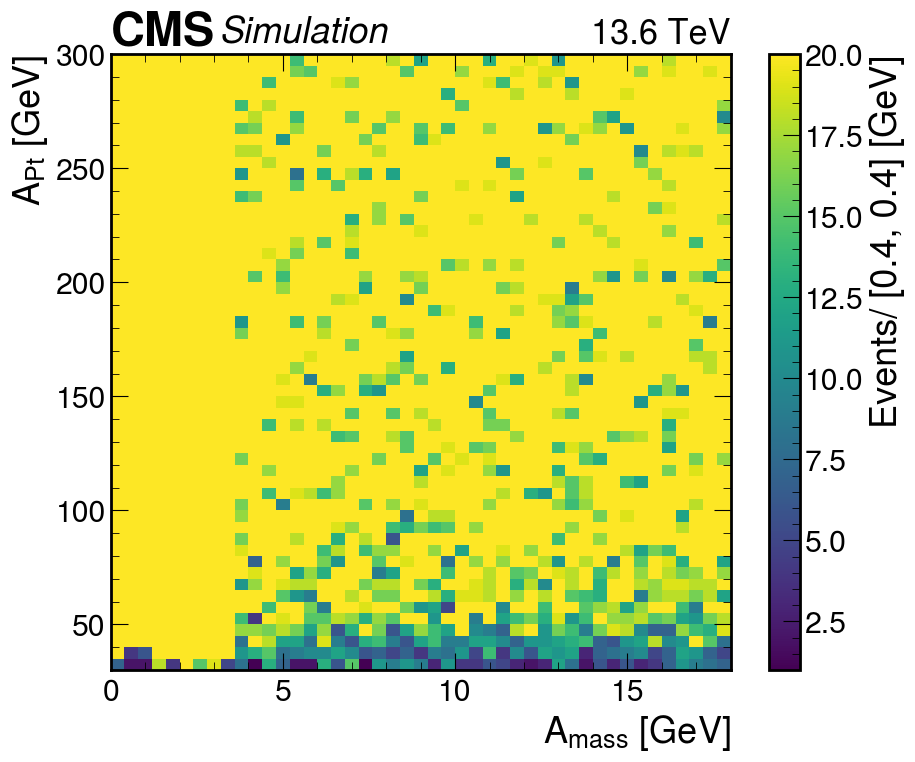

1.0 20.0 18.564609053497943


In [14]:
in_file6='IMG_ATo2Tau_m0To18_pt30To300_am_apt_from_AOD_unbiased_valid.pkl'
infile = open(f"{in_dir}/{in_file6}", "rb")
data = pickle.load(infile)
infile.close()
am = data['am']
apt = data['apt']
Total_files = data['Total_files']
Total_events = data['Total_events']
print("Toatal files :", Total_files , "Total events : ", Total_events, "Events_per_file", Total_events/Total_files)

m0_min=0
m0_max=18.1
bin_size =0.4
fig, ax = plt.subplots(figsize=(10,8), dpi=100)
counts, xedges, yedges, _ = plt.hist2d(am, apt, bins=[np.arange(m0_min,m0_max, .4), np.arange(30,301,5)])
plt.xlabel(r'${A_{mass}}$ [GeV]')
plt.ylabel(r'${A_{Pt}}$ [GeV]')
plt.colorbar().set_label(label='Events/ [0.4, 0.4] [GeV]' )
# plt.grid(color='r', linestyle='--', linewidth=.4)
hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig('%s/%d_mtrue_mpred_2D_hist_full.png'%(out_dir, epoch), bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()
print(np.min(counts), np.max(counts), np.mean(counts))

(array([1067., 1046., 1048., 1078., 1064., 1080., 1075., 1079., 1065.,
         972., 1001., 1030., 1001.,  963.,  988.,  989.,  989.,  993.,
         982.,  987.,  956.,  964.,  978.,  989.,  965., 1023.,  987.,
         995.,  961.,  986., 1016.,  985.,  985.,  958.,  958.,  979.,
         992., 1009.,  960., 1003.,  964.,  999.,  999., 1012.,  992.]),
 array([ 0. ,  0.4,  0.8,  1.2,  1.6,  2. ,  2.4,  2.8,  3.2,  3.6,  4. ,
         4.4,  4.8,  5.2,  5.6,  6. ,  6.4,  6.8,  7.2,  7.6,  8. ,  8.4,
         8.8,  9.2,  9.6, 10. , 10.4, 10.8, 11.2, 11.6, 12. , 12.4, 12.8,
        13.2, 13.6, 14. , 14.4, 14.8, 15.2, 15.6, 16. , 16.4, 16.8, 17.2,
        17.6, 18. ]),
 <BarContainer object of 45 artists>)

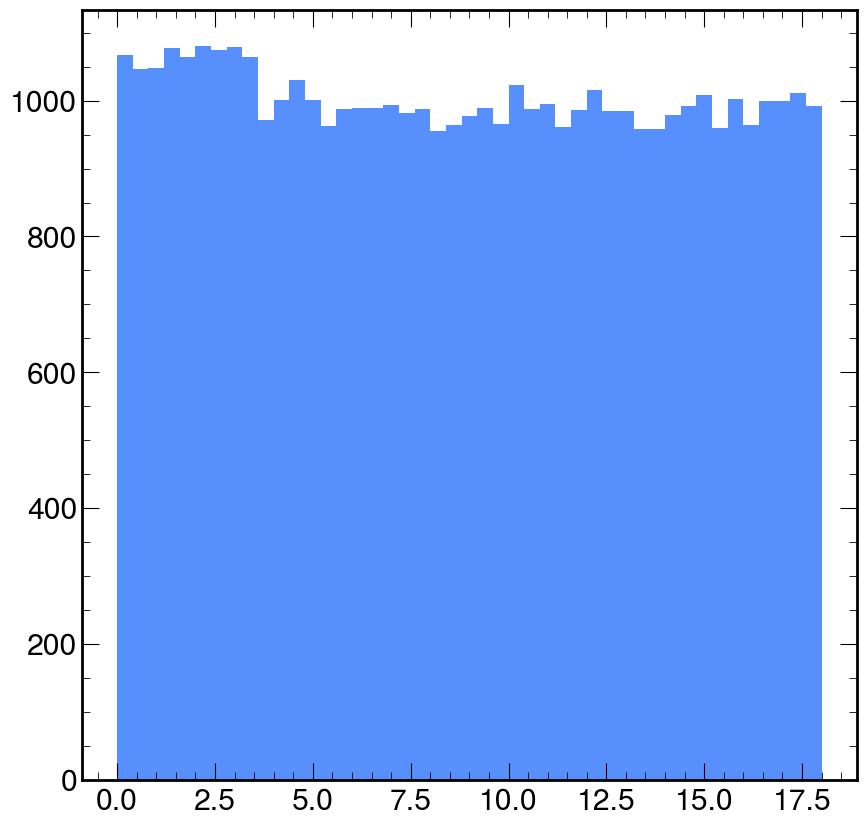

In [15]:
plt.hist(am, bins=np.arange(m0_min,m0_max, .4))